In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import mlflow
import mlflow.sklearn

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
mlflow.set_experiment("Rossmann_Demand_Forecasting")

<Experiment: artifact_location='file:///r:/Demand_Intelligence_Engine/notebooks/mlruns/1', creation_time=1782215951986, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1782215951986, lifecycle_stage='active', name='Rossmann_Demand_Forecasting', tags={}, trace_location=None, workspace='default'>

In [3]:
# Load model-ready dataset

import pandas as pd

df = pd.read_csv(
    "../data/processed/model_ready_data.csv"
)

print(df.shape)
df.head()

(985989, 42)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,Promo2,...,StateHoliday_c,Sales_Lag_7,Sales_Lag_14,Sales_Lag_28,Sales_RollingMean_7,Sales_RollingMean_14,Sales_RollingMean_28,Sales_RollingStd_7,Sales_RollingStd_14,Sales_RollingStd_28
0,1,2,2013-01-29,3725,522,1,0,0,1270.0,0,...,0,5720.0,3900.0,0.0,4533.142857,4170.500000,4121.285714,2080.017823,1899.595898,2075.631146
1,1,3,2013-01-30,4601,560,1,0,0,1270.0,0,...,0,5578.0,4008.0,5530.0,4248.142857,4158.000000,4254.321429,2026.274696,1902.086951,1914.845455
2,1,4,2013-01-31,4709,571,1,0,0,1270.0,0,...,0,5195.0,4044.0,4327.0,4108.571429,4200.357143,4221.142857,1951.681400,1905.090008,1899.913267
3,1,5,2013-02-01,5633,658,1,0,0,1270.0,0,...,0,5586.0,4127.0,4486.0,4039.142857,4247.857143,4234.785714,1914.889329,1909.177546,1902.071860
4,1,6,2013-02-02,5970,701,1,0,0,1270.0,0,...,0,5598.0,5182.0,4997.0,4045.857143,4355.428571,4275.750000,1921.288841,1943.954681,1919.949818


In [4]:
# Keep only open stores

open_df = df[df["Open"] == 1].copy()

print(open_df.shape)

open_df["Open"].value_counts()

(818845, 42)


Open
1    818845
Name: count, dtype: int64

In [5]:
split_date = "2015-06-01"

train_open = open_df[
    open_df["Date"] < split_date
].copy()

valid_open = open_df[
    open_df["Date"] >= split_date
].copy()

print(train_open.shape)
print(valid_open.shape)

(760234, 42)
(58611, 42)


## Experiment 2: Customer Demand Forecasting

In [6]:
# Customer demand forecasting

customer_drop_cols = [
    "Sales",
    "Customers",
    "Date",

    "Sales_Lag_7",
    "Sales_Lag_14",
    "Sales_Lag_28",

    "Sales_RollingMean_7",
    "Sales_RollingMean_14",
    "Sales_RollingMean_28",

    "Sales_RollingStd_7",
    "Sales_RollingStd_14",
    "Sales_RollingStd_28"
]



In [7]:
split_date = "2015-06-01"

train_df = open_df[
    open_df["Date"] < split_date
].copy()

valid_df = open_df[
    open_df["Date"] >= split_date
].copy()

print(train_df.shape)
print(valid_df.shape)

(760234, 42)
(58611, 42)


In [8]:
X_train_cust = train_df.drop(columns=customer_drop_cols)
y_train_cust = train_df["Customers"]

X_valid_cust = valid_df.drop(columns=customer_drop_cols)
y_valid_cust = valid_df["Customers"]

print(X_train_cust.shape)
print(X_valid_cust.shape)

(760234, 30)
(58611, 30)


In [9]:
sales_drop_cols = [
    "Sales",
    "Date",
    "Open",
    "Customers"
]

In [10]:
from xgboost import XGBRegressor

cust_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [11]:
cust_xgb.fit(
    X_train_cust,
    y_train_cust
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [12]:
cust_preds = cust_xgb.predict(
    X_valid_cust
)

In [13]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

In [14]:
cust_mae = mean_absolute_error(
    y_valid_cust,
    cust_preds
)

cust_rmse = np.sqrt(
    mean_squared_error(
        y_valid_cust,
        cust_preds
    )
)

cust_r2 = r2_score(
    y_valid_cust,
    cust_preds
)

print("Customer Forecast Results")
print("-" * 35)
print(f"MAE  : {cust_mae:.2f}")
print(f"RMSE : {cust_rmse:.2f}")
print(f"R²   : {cust_r2:.4f}")

Customer Forecast Results
-----------------------------------
MAE  : 101.37
RMSE : 135.13
R²   : 0.8810


In [15]:
valid_open["Predicted_Customers"] = cust_preds


In [16]:
train_pipeline = train_open.copy()
valid_pipeline = valid_open.copy()

In [17]:
valid_pipeline["Predicted_Customers"] = cust_preds

## Sales Forecasting with Customer Demand

In [18]:
train_pred_customers = cust_xgb.predict(X_train_cust)
valid_pred_customers = cust_xgb.predict(X_valid_cust)

In [19]:
train_pipeline = train_open.copy()
valid_pipeline = valid_open.copy()

train_pipeline["Predicted_Customers"] = train_pred_customers
valid_pipeline["Predicted_Customers"] = valid_pred_customers

In [20]:
sales_drop_cols = [
    "Sales",
    "Date",
    "Open",
    "Customers"
]

In [21]:
X_train_pipeline = train_pipeline.drop(
    columns=sales_drop_cols
)

X_valid_pipeline = valid_pipeline.drop(
    columns=sales_drop_cols
)

y_train_pipeline = train_pipeline["Sales"]
y_valid_pipeline = valid_pipeline["Sales"]

In [22]:
print(X_train_pipeline.shape)
print(X_valid_pipeline.shape)

(760234, 39)
(58611, 39)


In [23]:

print(
    "Predicted_Customers" in X_train_pipeline.columns
)

print(
    "Customers" in X_train_pipeline.columns
)

True
False


In [24]:
pipeline_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)


In [25]:
pipeline_xgb.fit(
    X_train_pipeline,
    y_train_pipeline
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [26]:
pipeline_preds = pipeline_xgb.predict(
    X_valid_pipeline
)

In [27]:
pipeline_mae = mean_absolute_error(
    y_valid_pipeline,
    pipeline_preds
)

pipeline_rmse = np.sqrt(
    mean_squared_error(
        y_valid_pipeline,
        pipeline_preds
    )
)

pipeline_r2 = r2_score(
    y_valid_pipeline,
    pipeline_preds
)

print("Two-Stage Pipeline Results")
print("-"*35)
print(f"MAE  : {pipeline_mae:.2f}")
print(f"RMSE : {pipeline_rmse:.2f}")
print(f"R²   : {pipeline_r2:.4f}")

Two-Stage Pipeline Results
-----------------------------------
MAE  : 616.70
RMSE : 872.60
R²   : 0.9213


In [28]:
with mlflow.start_run(run_name="Two_Stage_XGBoost"):
    from xgboost import XGBRegressor

    cust_xgb = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    cust_xgb.fit(
        X_train_cust,
        y_train_cust
    )


    train_pred_customers = cust_xgb.predict(X_train_cust)
    valid_pred_customers = cust_xgb.predict(X_valid_cust)

    train_pipeline = train_open.copy()
    valid_pipeline = valid_open.copy()

    train_pipeline["Predicted_Customers"] = train_pred_customers
    valid_pipeline["Predicted_Customers"] = valid_pred_customers


    X_train_pipeline = train_pipeline.drop(
        columns=sales_drop_cols
    )

    X_valid_pipeline = valid_pipeline.drop(
        columns=sales_drop_cols
    )

    y_train_pipeline = train_pipeline["Sales"]
    y_valid_pipeline = valid_pipeline["Sales"]

    pipeline_xgb = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    pipeline_xgb.fit(
        X_train_pipeline,
        y_train_pipeline
    )

    pipeline_preds = pipeline_xgb.predict(
        X_valid_pipeline
    )

    

In [29]:
mlflow.set_tag("model_family", "two_stage_pipeline")
mlflow.set_tag("dataset_type", "open_stores")
mlflow.set_tag("business_use_case", "hierarchical_sales_forecasting")

In [30]:
# Pipeline Information
mlflow.log_param("pipeline_type", "two_stage")
mlflow.log_param("customer_model", "XGBoost")
mlflow.log_param("sales_model", "XGBoost")

# Shared Hyperparameters
mlflow.log_param("n_estimators", 300)
mlflow.log_param("learning_rate", 0.05)
mlflow.log_param("max_depth", 8)
mlflow.log_param("subsample", 0.8)
mlflow.log_param("colsample_bytree", 0.8)
mlflow.log_param("random_state", 42)

42

In [31]:
mlflow.log_metric("customer_mae", cust_mae)
mlflow.log_metric("customer_rmse", cust_rmse)
mlflow.log_metric("customer_r2", cust_r2)
mlflow.log_metric("sales_mae", pipeline_mae)
mlflow.log_metric("sales_rmse", pipeline_rmse)
mlflow.log_metric("sales_r2", pipeline_r2)

In [32]:
mlflow.xgboost.log_model(
    cust_xgb,
    name="customer_xgb_model"
)

mlflow.xgboost.log_model(
    pipeline_xgb,
    name="sales_xgb_model"
)

In [33]:
customer_importance = pd.DataFrame({
    "Feature": X_train_cust.columns,
    "Importance": cust_xgb.feature_importances_
}).sort_values("Importance", ascending=False)

customer_importance.head(20)

,Feature,Importance
22,StoreType_b,0.488597
25,Assortment_b,0.216306
24,StoreType_d,0.047802
5,CompetitionDistance,0.038423
6,Promo2,0.028974
0,Store,0.025071
26,Assortment_c,0.023227
3,Promo,0.021062
23,StoreType_c,0.019506
18,CompetitionDateKnown,0.017150


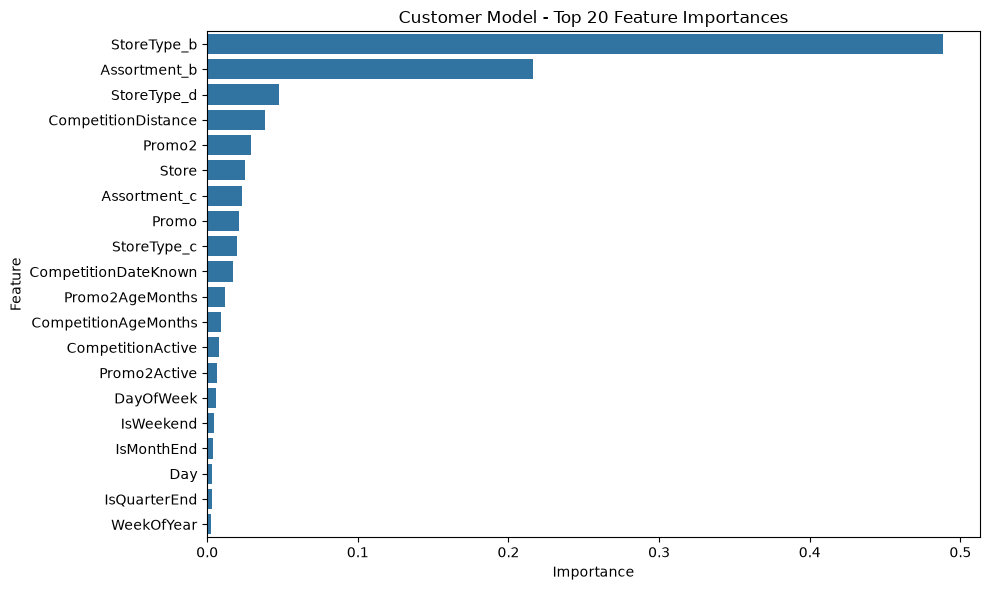

In [34]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=customer_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Customer Model - Top 20 Feature Importances")
plt.tight_layout()

plt.savefig("customer_feature_importance.png")

mlflow.log_artifact("customer_feature_importance.png")

plt.show()

In [35]:
sales_importance = pd.DataFrame({
    "Feature": X_train_pipeline.columns,
    "Importance": pipeline_xgb.feature_importances_
}).sort_values("Importance", ascending=False)

sales_importance.head(20)

,Feature,Importance
30,Sales_Lag_14,0.281799
38,Predicted_Customers,0.127983
2,Promo,0.109829
34,Sales_RollingMean_28,0.097272
31,Sales_Lag_28,0.087534
33,Sales_RollingMean_14,0.048995
35,Sales_RollingStd_7,0.032509
23,StoreType_d,0.020579
15,IsWeekend,0.019603
12,IsMonthEnd,0.018149


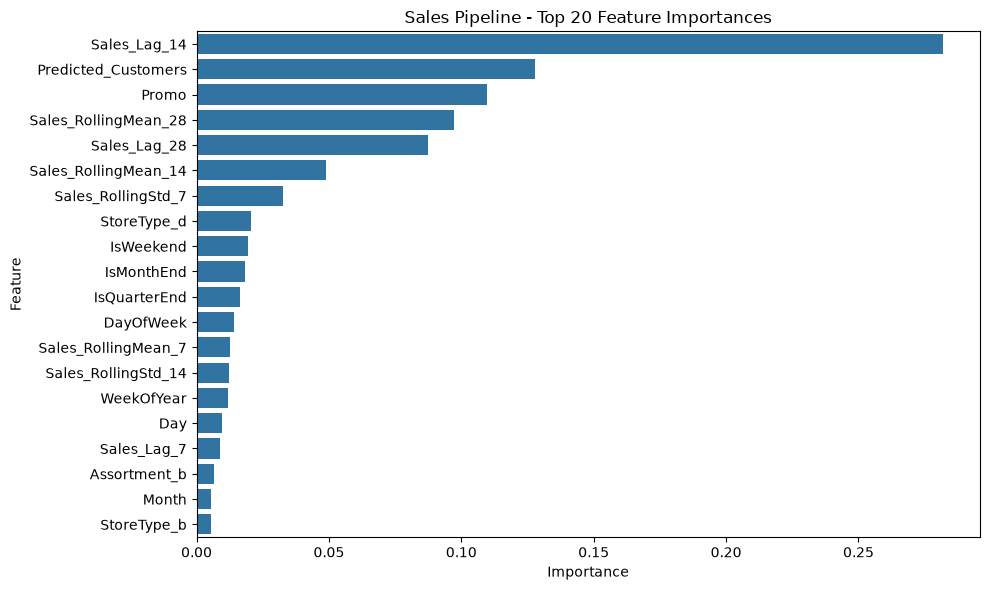

In [36]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=sales_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Sales Pipeline - Top 20 Feature Importances")
plt.tight_layout()

plt.savefig("sales_feature_importance.png")

mlflow.log_artifact("sales_feature_importance.png")

plt.show()

In [38]:
test_df=pd.read_csv("../data/raw/rossmann/test.csv")

In [39]:
test_df.shape

(41088, 8)

In [40]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             41088 non-null  int64  
 1   Store          41088 non-null  int64  
 2   DayOfWeek      41088 non-null  int64  
 3   Date           41088 non-null  object 
 4   Open           41077 non-null  float64
 5   Promo          41088 non-null  int64  
 6   StateHoliday   41088 non-null  object 
 7   SchoolHoliday  41088 non-null  int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 2.5+ MB


In [42]:
import joblib

joblib.dump(
    pipeline_xgb,
    "../models/xgboost_open_store.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [43]:
joblib.dump(
    cust_xgb,
    "../models/xgboost_open_store_cust.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [44]:
joblib.dump(
    cust_xgb,
    "../models/two_stage_customer_xgb_v1.pkl"
)

joblib.dump(
    pipeline_xgb,
    "../models/two_stage_sales_xgb_v1.pkl"
)

['../models/two_stage_sales_xgb_v1.pkl']

In [45]:
import shap

In [46]:
sales_model = pipeline_xgb

In [47]:
customer_model = cust_xgb

In [48]:
explainer = shap.TreeExplainer(sales_model)

In [49]:
#using only random limited sample of 1000 rows to speed up the process
X_shap = X_valid_pipeline.sample(
    n=1000,
    random_state=42
)

In [50]:
shap_values = explainer.shap_values(X_shap)

In [51]:
print(shap_values.shape)
print(X_shap.shape)

(1000, 39)
(1000, 39)


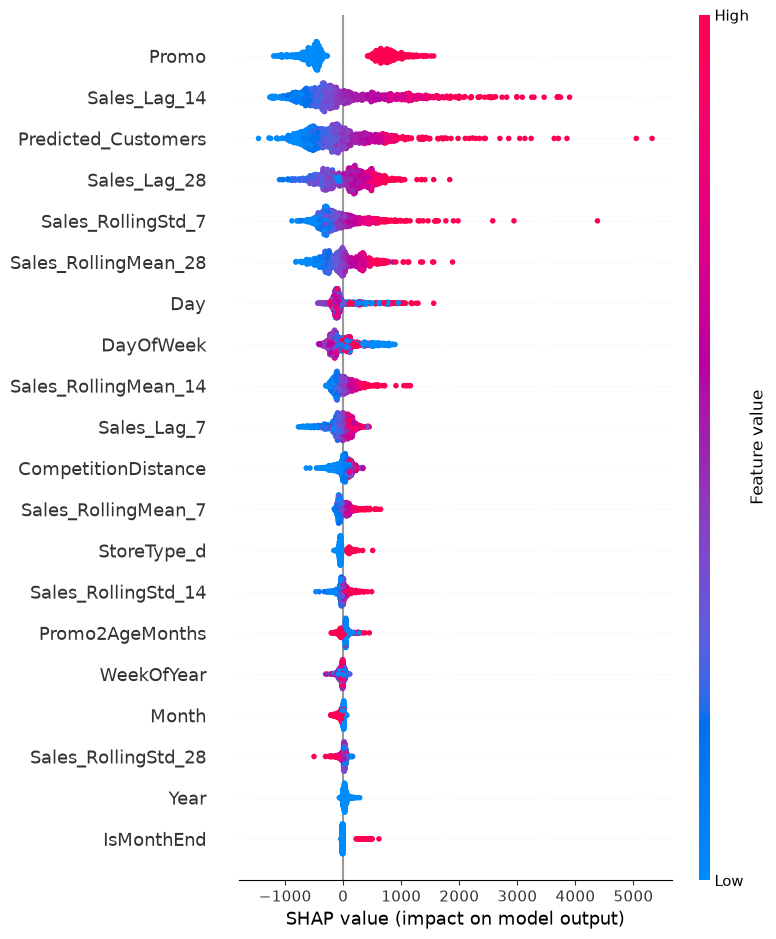

In [52]:
plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values,
    X_shap,
    show=False
)

plt.tight_layout()
plt.show()

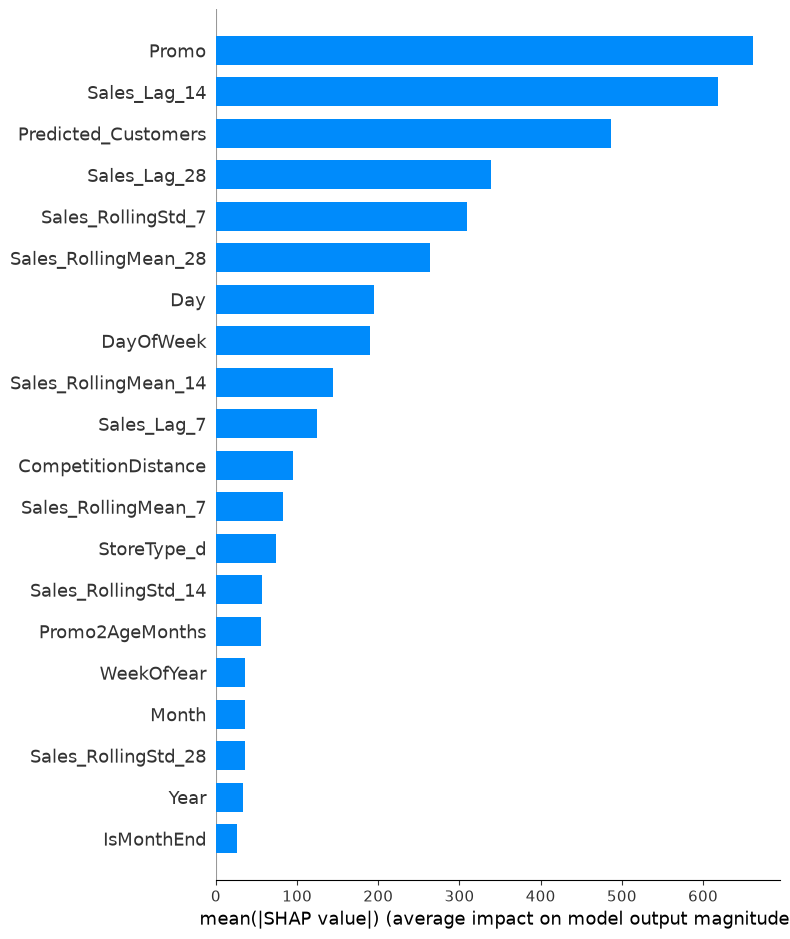

In [53]:
plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.show()

In [54]:
feature_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_SHAP": np.abs(shap_values).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    "Mean_SHAP",
    ascending=False
)

feature_importance.head(15)

,Feature,Mean_SHAP
2,Promo,661.653076
30,Sales_Lag_14,617.991516
38,Predicted_Customers,486.893402
31,Sales_Lag_28,339.134247
35,Sales_RollingStd_7,308.746521
34,Sales_RollingMean_28,263.435516
9,Day,194.535492
1,DayOfWeek,189.204559
33,Sales_RollingMean_14,143.648621
29,Sales_Lag_7,124.915268


### Business Interpretation

The SHAP analysis provides a global explanation of the Two-Stage XGBoost forecasting model.

Promotional activity emerged as the single most influential factor affecting sales predictions, highlighting the significant role of promotional campaigns in driving customer demand.

Historical demand indicators, including lag features and rolling statistics, also contributed strongly to the model's decisions. This demonstrates that the model effectively captures temporal demand patterns and recent sales trends.

The `Predicted_Customers` feature, generated by the first stage of the pipeline, ranked among the top three most influential predictors. This validates the effectiveness of the Two-Stage forecasting architecture, indicating that customer demand forecasts provide valuable information for predicting future sales.

Competition-related features showed comparatively lower influence, suggesting that short-term promotional strategies and historical demand patterns play a more dominant role in explaining store-level sales.

Overall, the SHAP analysis confirms that the model bases its predictions on meaningful business factors rather than relying on arbitrary correlations, increasing confidence in its deployment for decision support applications.

<Figure size 800x600 with 0 Axes>

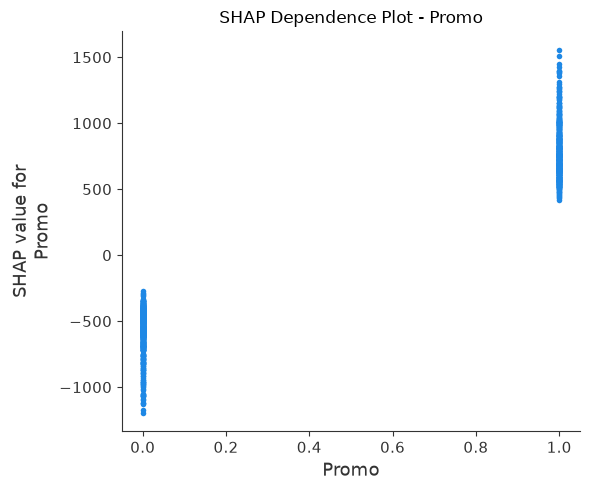

In [55]:
plt.figure(figsize=(8,6))

shap.dependence_plot(
    "Promo",
    shap_values,
    X_shap,
    interaction_index=None,
    show=False
)

plt.title("SHAP Dependence Plot - Promo")

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

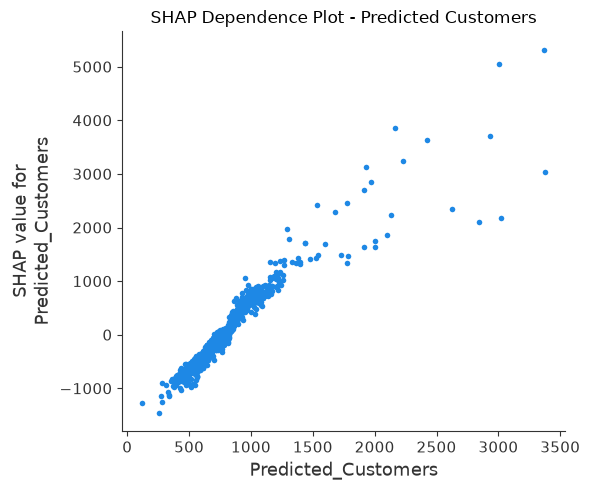

In [56]:
plt.figure(figsize=(8,6))

shap.dependence_plot(
    "Predicted_Customers",
    shap_values,
    X_shap,
    interaction_index=None,
    show=False
)

plt.title("SHAP Dependence Plot - Predicted Customers")

plt.tight_layout()
plt.show()

In [57]:
index = 25      # Change to any row you want

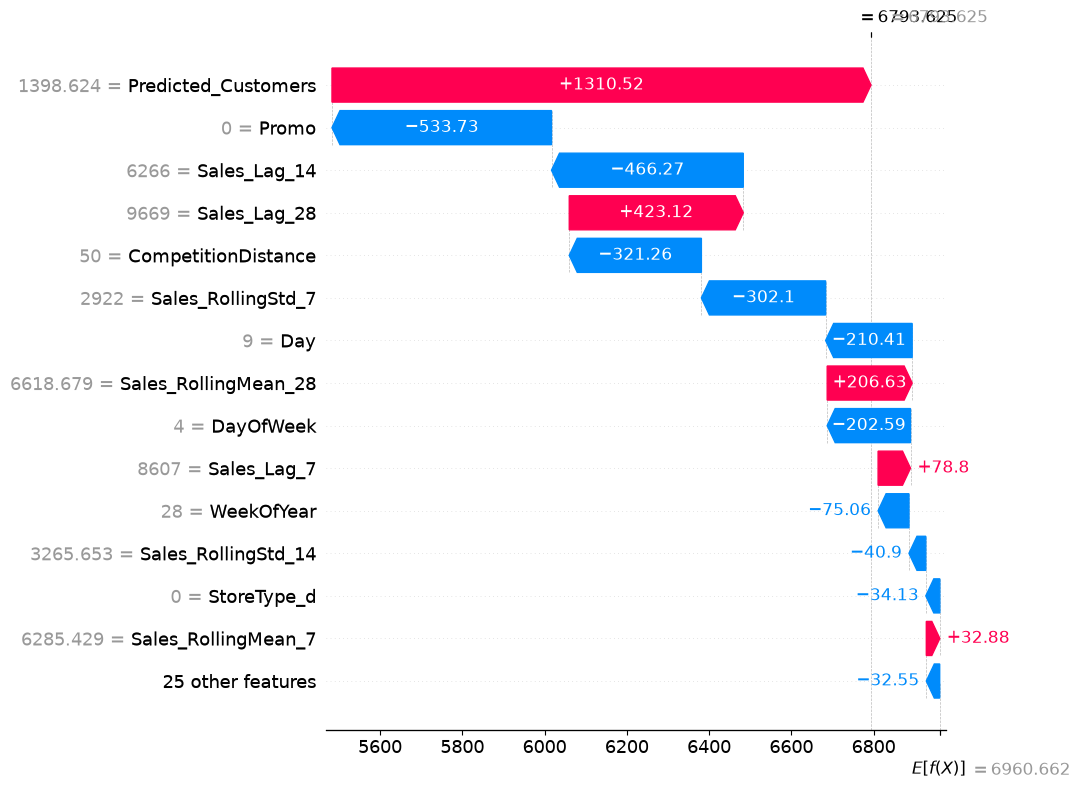

In [58]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[index],
        base_values=explainer.expected_value,
        data=X_shap.iloc[index],
        feature_names=X_shap.columns
    ),
    max_display=15
)

In [ ]:
#force plot visualization - 
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[index],
    X_shap.iloc[index]
)

In [60]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[index],
    X_shap.iloc[index]
)

In [61]:
import joblib

joblib.dump(
    explainer,
    "../models/shap_explainer.pkl"
)

['../models/shap_explainer.pkl']

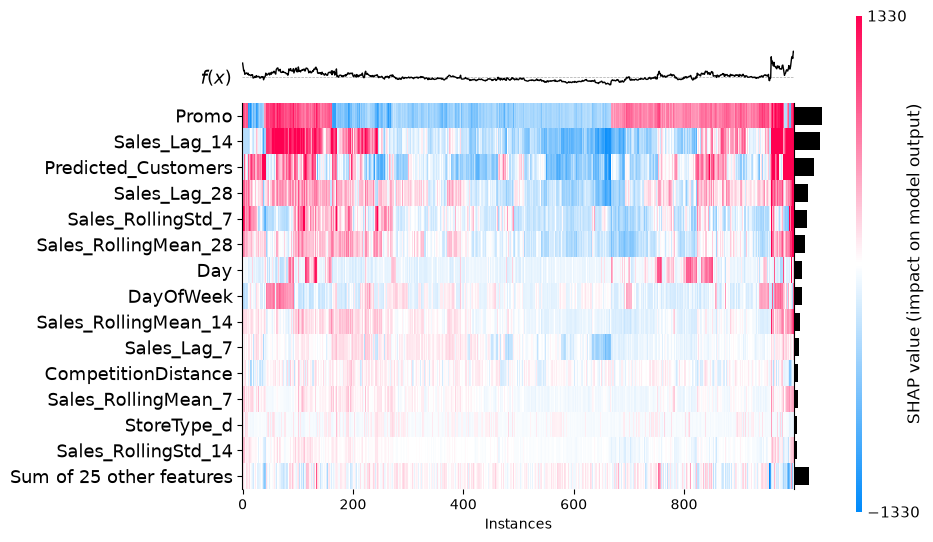

<Axes: xlabel='Instances'>

In [62]:
shap.plots.heatmap(
    shap.Explanation(
        values=shap_values,
        base_values=np.repeat(explainer.expected_value, len(X_shap)),
        data=X_shap.values,
        feature_names=X_shap.columns
    ),
    max_display=15
)

In [63]:
# Top 5 features based on mean absolute SHAP values
top_features = feature_importance.head(5)["Feature"].tolist()

print(top_features)

['Promo', 'Sales_Lag_14', 'Predicted_Customers', 'Sales_Lag_28', 'Sales_RollingStd_7']


<Figure size 800x600 with 0 Axes>

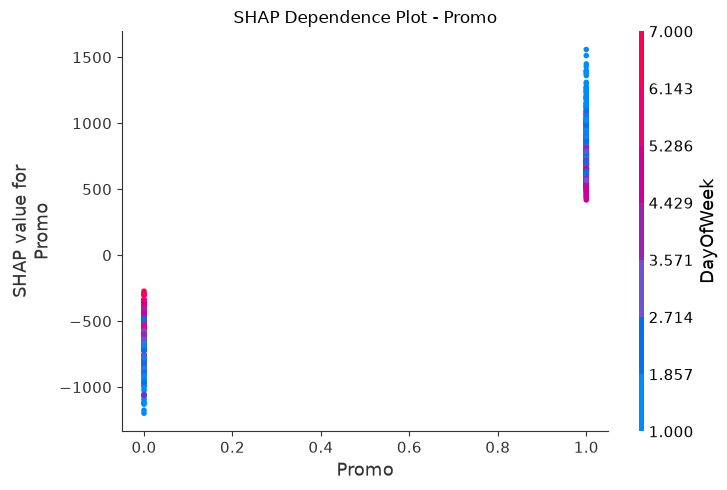

<Figure size 800x600 with 0 Axes>

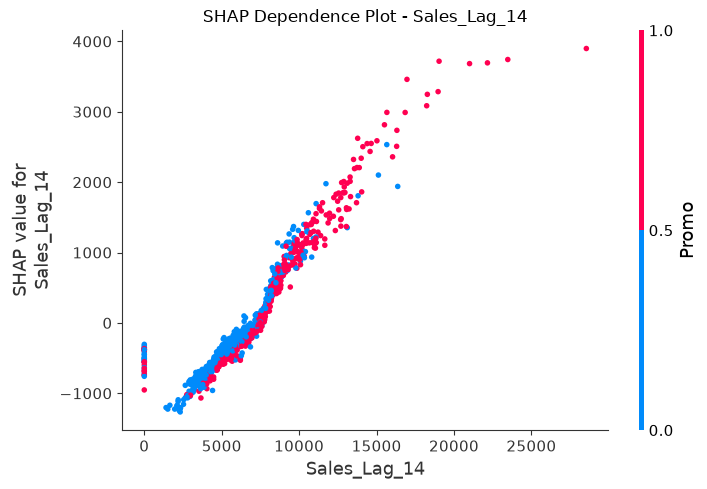

<Figure size 800x600 with 0 Axes>

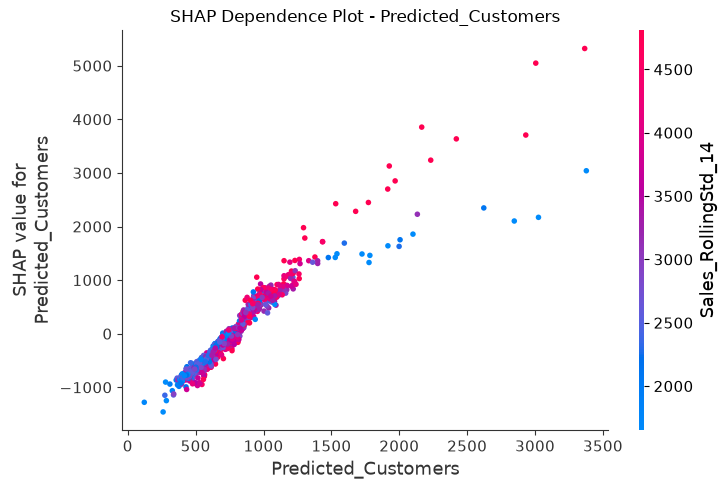

<Figure size 800x600 with 0 Axes>

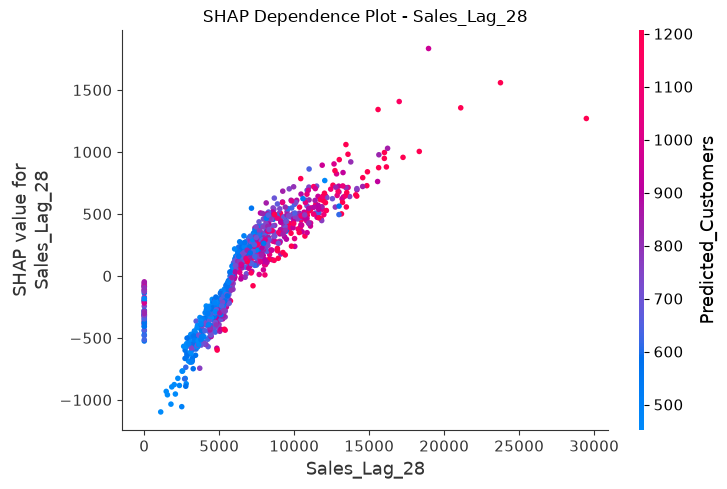

<Figure size 800x600 with 0 Axes>

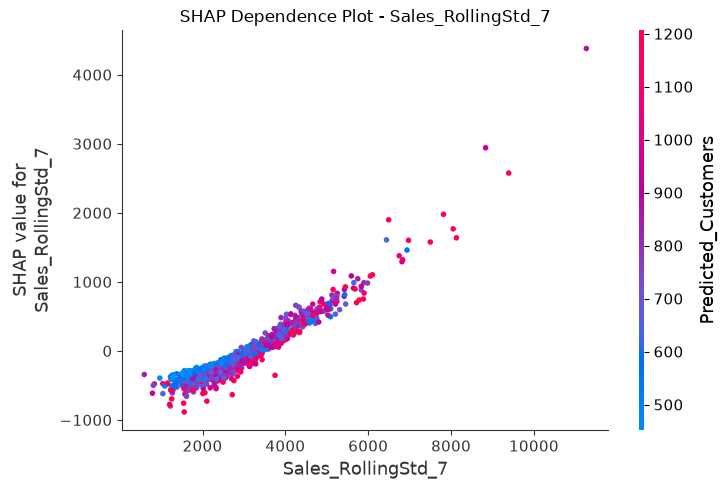

In [64]:
for feature in top_features:
    plt.figure(figsize=(8, 6))

    shap.dependence_plot(
        feature,
        shap_values,
        X_shap,
        interaction_index="auto",
        show=False
    )

    plt.title(f"SHAP Dependence Plot - {feature}")
    plt.tight_layout()
    plt.show()